In [1]:
import mlflow

In [26]:
mlflow.set_tracking_uri("http://127.0.0.1:5000")

In [27]:
import mlflow.artifacts
import mlflow.experiments
import mlflow.artifacts
import pickle

runs = mlflow.search_runs(experiment_ids=["570883796492569929"])
from sklearn.metrics import roc_auc_score, matthews_corrcoef
import pandas as pd
from tqdm import tqdm
from collections import defaultdict

In [28]:
results_archs = []
predictions_all = defaultdict()
for index, row in tqdm(runs.iterrows()):
    chr = (
        row["tags.mlflow.runName"]
        .replace("_cpg_counts_selected", "")
        .replace("chromosome_", "")
    )
    trimming_type = "naive_cut"
    trimming_l = 150
    arch = row["tags.architecture"]
    tmp_path = mlflow.artifacts.download_artifacts(
        row["artifact_uri"] + "/predictions/test_predictions.pkl"
    )
    f = open(tmp_path, "rb")
    predictions = pickle.load(f)
    predictions_all[arch] = predictions
    f.close()
    mcc = matthews_corrcoef(
        predictions["true_label"], predictions["predicted_probability"] > 0.5
    )
    rocauc = roc_auc_score(
        predictions["true_label"], predictions["predicted_probability"]
    )
    results_archs.append((chr, trimming_type, rocauc, mcc, arch, trimming_l))

4it [00:00, 15.64it/s]


In [52]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator


def cohen_d(group1, group2):
    """
    Computes Cohen's d to measure effect size between two distributions.
    Implemented based on ConceptsOfBiometrics.pdf, slide 77.

    Parameters:
    - group1, group2: Arrays of numerical values.

    Returns:
    - Cohen's d value (effect size).
    """
    mean1, mean2 = np.mean(group1), np.mean(group2)
    n1, n2 = len(group1), len(group2)
    std1, std2 = np.std(group1, ddof=1), np.std(group2, ddof=1)  # Unbiased std
    pooled_std = np.sqrt(((n1 - 1) * std1**2 + (n2 - 1) * std2**2) / (n1 + n2 - 2))
    return abs((mean1 - mean2)) / pooled_std


def plot_filled_kde(
    values, groups, alpha=0.4, ax=None, bw_adjust=0.4, name="Default", figsize=(10, 6)
):
    """
    Plots overlapping KDE (Kernel Density Estimation) curves with filled areas for two groups (0 and 1).
    Also computes Cohen's d to measure effect size.

    Parameters:
    - values: A list or numpy array of numerical values.
    - groups: A list or numpy array of group labels (0 or 1).
    - alpha: Transparency level for the filled area under KDE curves (default is 0.4).
    - ax: Matplotlib axis to plot on (optional).
    """
    # Convert to numpy arrays
    values = np.array(values)
    groups = np.array(groups)

    # Ensure groups contain only 0s and 1s
    unique_groups = np.unique(groups)
    if len(unique_groups) > 2 or set(unique_groups) - {0, 1}:
        raise ValueError("Groups should contain only 0 and 1.")

    # Separate values by group
    values_0 = values[groups == 0]  # Impostor scores
    values_1 = values[groups == 1]  # Genuine scores

    # Compute Uniquness and permanence
    uniqueness = np.abs(np.mean(values_0) - np.mean(values_1))

    n1, n2 = len(values_0), len(values_1)
    std1, std2 = np.std(values_0, ddof=1), np.std(values_1, ddof=1)  # Unbiased std
    pooled_std = np.sqrt(((n1 - 1) * std1**2 + (n2 - 1) * std2**2) / (n1 + n2 - 2))
    d_value = cohen_d(values_0, values_1)
    # permanence = pooled_std

    # If no axis is provided, create one
    if ax is None:
        fig, ax = plt.subplots(figsize=figsize)

    # KDE plots with filled area
    sns.kdeplot(
        values_0,
        color="blue",
        fill=True,
        alpha=alpha,
        label="Normal",
        linewidth=2,
        ax=ax,
        bw_adjust=bw_adjust,
    )
    sns.kdeplot(
        values_1,
        color="red",
        fill=True,
        alpha=alpha,
        label="Tumour",
        linewidth=2,
        ax=ax,
        bw_adjust=bw_adjust,
    )

    # Labels and legend
    ax.set_xlabel("Model Score", fontsize=20)
    ax.set_ylabel("Density", fontsize=20)
    # ax.set_title(f"{name} Cohen's d: {d_value:.2f}")
    print(f"{name} Cohen's d: {d_value:.2f}")
    #  \n Means Difference: {uniqueness:.3f}, \n Pooled StDev: {pooled_std:.3f})
    ax.legend(fontsize=20)
    plt.xticks(fontsize=20)
    plt.yticks(fontsize=20)
    ax.set_xlim(0, 1)
    ax.grid(True, linestyle="--", alpha=0.6)
    # ax.xaxis.set_major_locator(MaxNLocator(integer=True))

    # If ax is None, show the plot
    if ax is None:
        plt.show()

In [63]:
model = "dismir_lstm"
roc_score = round(
    roc_auc_score(
        predictions_all[model]["true_label"],
        predictions_all[model]["predicted_probability"],
    )
    * 100,
    1,
)
if model == "dnabert2":
    model_name = "DNABERT-2E"
elif model == "methylbert":
    model_name = "MetthylBERT"
elif model == "dismir_minigru":
    model_name = "Dismir-A"
else:
    model_name = "Dismir"

name = f"{model_name} || ROC-AUC: {roc_score}% ||"

Dismir || ROC-AUC: 95.2% || Cohen's d: 3.35


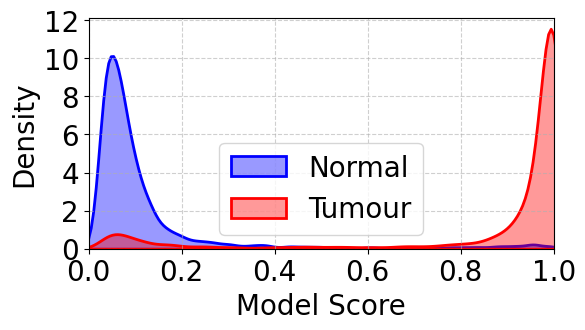

In [64]:
plot_filled_kde(
    values=predictions_all[model]["predicted_probability"],
    groups=predictions_all[model]["true_label"],
    figsize=(6, 3),
    name=name,
)

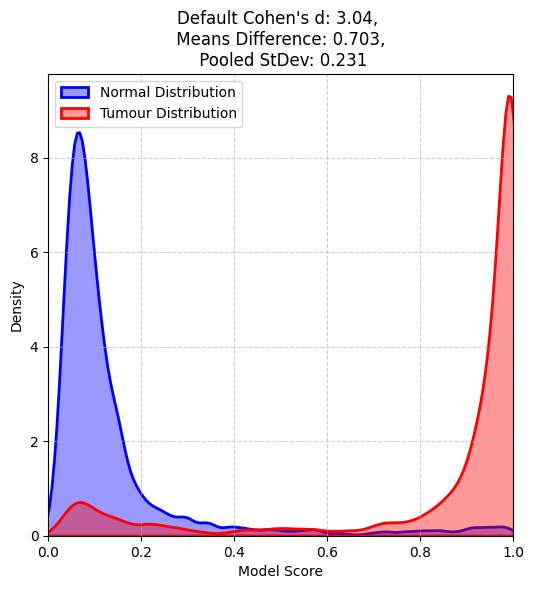

In [14]:
plot_filled_kde(
    values=predictions_all["dismir_minigru"]["predicted_probability"],
    groups=predictions_all["dnabert2"]["true_label"],
    figsize=(6, 6),
)

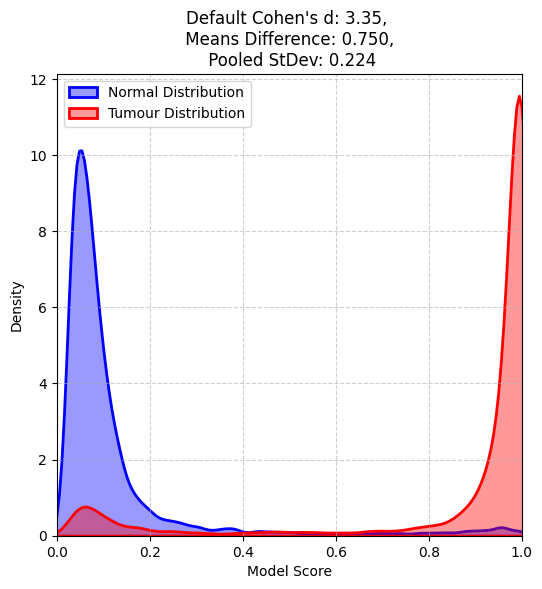

In [15]:
plot_filled_kde(
    values=predictions_all["dismir_lstm"]["predicted_probability"],
    groups=predictions_all["dnabert2"]["true_label"],
    figsize=(6, 6),
)